In [1]:
import torch
import torchvision
import torchvision.transforms as transforms

########################################################################
# The output of torchvision datasets are PILImage images of range [0, 1].
# We transform them to Tensors of normalized range [-1, 1].

trainTransform = transforms.Compose(
    [transforms.RandomResizedCrop(32),
     transforms.RandomHorizontalFlip(),
     transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

testTransform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])


trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=trainTransform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=testTransform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:02<00:00, 64.7MB/s]


In [2]:
########################################################################
# 2. Define a Convolution Neural Network
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
# Copy the neural network from the Neural Networks section before and modify it to
# take 3-channel images (instead of 1-channel images as it was defined).

import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 110)
        self.fc2 = nn.Linear(110, 74)
        self.fc3 = nn.Linear(74, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net()

########################################################################
# 3. Define a Loss function and optimizer
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
# Let's use a Classification Cross-Entropy loss and SGD with momentum.

import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

########################################################################
# 4. Train the network
# ^^^^^^^^^^^^^^^^^^^^
#
# This is when things start to get interesting.
# We simply have to loop over our data iterator, and feed the inputs to the
# network and optimize.

epochLoss = []
trainAccur = []
testAccur = []

numEpoch = 50

epoch_loss = 0
counter = 0

for epoch in range(numEpoch):  # loop over the dataset multiple times

    running_loss = 0.0

    for i, data in enumerate(trainloader, 0):
        # get the inputs
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        epoch_loss += loss.item()
        counter += 1
        if i % 10000 == 9999:    # print every 10000 mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 10000))
            running_loss = 0.0
    epochLoss.append(epoch_loss / counter)
    epoch_loss = 0
    counter = 0

  # Finding the training accuracy of the model after the epoch

    correct = 0
    total = 0
    with torch.no_grad():
        for data in trainloader:
            images, labels = data
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    trainAccur.append(100 * correct / total)

    # Finding the test accuracy of the model after the epoch

    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    testAccur.append(100 * correct / total)

print('Finished Training')

[1, 10000] loss: 2.010
[2, 10000] loss: 1.759
[3, 10000] loss: 1.692
[4, 10000] loss: 1.646
[5, 10000] loss: 1.616
[6, 10000] loss: 1.592
[7, 10000] loss: 1.578
[8, 10000] loss: 1.560
[9, 10000] loss: 1.547
[10, 10000] loss: 1.529
[11, 10000] loss: 1.519
[12, 10000] loss: 1.508
[13, 10000] loss: 1.503
[14, 10000] loss: 1.495
[15, 10000] loss: 1.495
[16, 10000] loss: 1.491
[17, 10000] loss: 1.483
[18, 10000] loss: 1.483
[19, 10000] loss: 1.478
[20, 10000] loss: 1.471
[21, 10000] loss: 1.476
[22, 10000] loss: 1.464
[23, 10000] loss: 1.470
[24, 10000] loss: 1.468
[25, 10000] loss: 1.460
[26, 10000] loss: 1.461
[27, 10000] loss: 1.456
[28, 10000] loss: 1.455
[29, 10000] loss: 1.459
[30, 10000] loss: 1.452
[31, 10000] loss: 1.450
[32, 10000] loss: 1.453
[33, 10000] loss: 1.447
[34, 10000] loss: 1.451
[35, 10000] loss: 1.444
[36, 10000] loss: 1.441
[37, 10000] loss: 1.439
[38, 10000] loss: 1.440
[39, 10000] loss: 1.440
[40, 10000] loss: 1.444
[41, 10000] loss: 1.448
[42, 10000] loss: 1.430
[

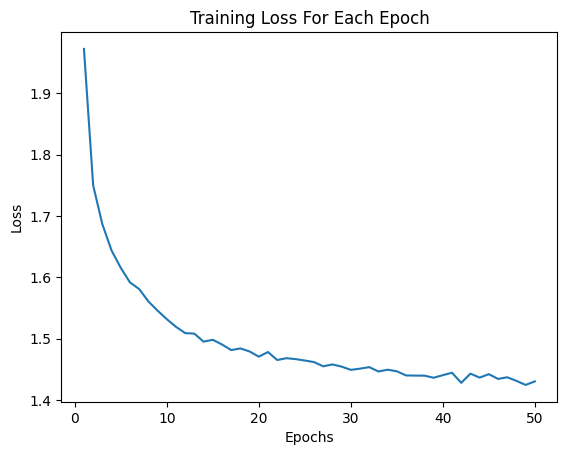

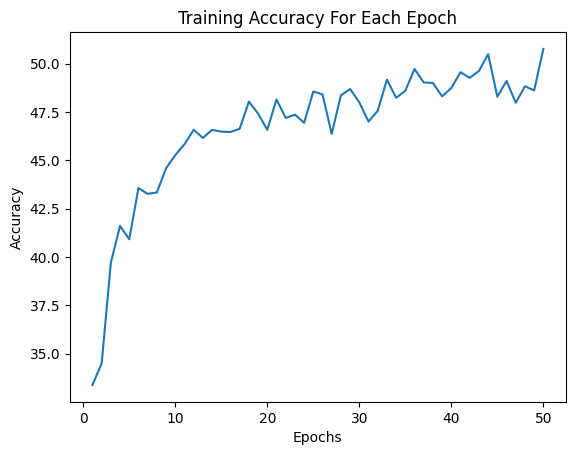

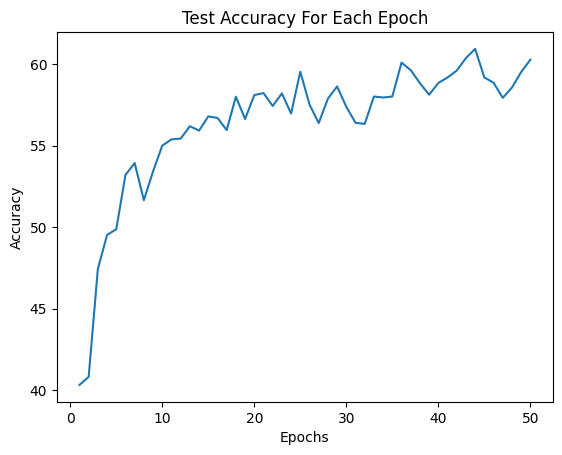

In [3]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(1,numEpoch+1)

plt.plot(x,epochLoss)
plt.title("Training Loss For Each Epoch")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

plt.plot(x,trainAccur)
plt.title("Training Accuracy For Each Epoch")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

plt.plot(x,testAccur)
plt.title("Test Accuracy For Each Epoch")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()